In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc


In [2]:
df = pd.read_csv('/content/heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [6]:
X = df.drop('num', axis=1)
y = df['num']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
print(X.dtypes)

id                            int64
age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                       bool
dataset_Hungary                bool
dataset_Switzerland            bool
dataset_VA Long Beach          bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
fbs_True                       bool
restecg_normal                 bool
restecg_st-t abnormality       bool
exang_True                     bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   trestbps                  861 non-null    float64
 3   chol                      890 non-null    float64
 4   thalch                    865 non-null    float64
 5   oldpeak                   858 non-null    float64
 6   ca                        309 non-null    float64
 7   sex_Male                  920 non-null    bool   
 8   dataset_Hungary           920 non-null    bool   
 9   dataset_Switzerland       920 non-null    bool   
 10  dataset_VA Long Beach     920 non-null    bool   
 11  cp_atypical angina        920 non-null    bool   
 12  cp_non-anginal            920 non-null    bool   
 13  cp_typical angina         920 non-null    bool   
 14  fbs_True  

In [28]:
from sklearn.impute import SimpleImputer

# X is already one-hot encoded but has NaNs in numerical columns
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Columns that still have NaNs
numerical_cols_with_nans = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Impute missing numerical values with mean imputation
imputer_numerical = SimpleImputer(strategy='mean')

# Apply imputation to the identified columns in X_train_df and X_test_df
# Use .loc for explicit assignment to avoid potential SettingWithCopyWarning issues
X_train_df.loc[:, numerical_cols_with_nans] = imputer_numerical.fit_transform(X_train_df[numerical_cols_with_nans])
X_test_df.loc[:, numerical_cols_with_nans] = imputer_numerical.transform(X_test_df[numerical_cols_with_nans])

# Now, apply StandardScaler - converts DataFrames to NumPy arrays
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

In [29]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5597826086956522


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.88      0.78        75
           1       0.49      0.56      0.52        54
           2       0.22      0.08      0.12        25
           3       0.29      0.19      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.56       184
   macro avg       0.34      0.34      0.33       184
weighted avg       0.50      0.56      0.52       184



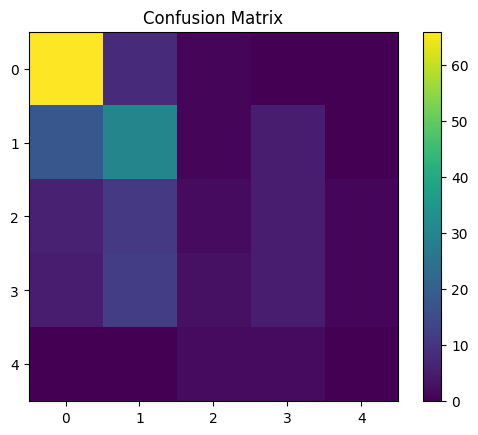

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

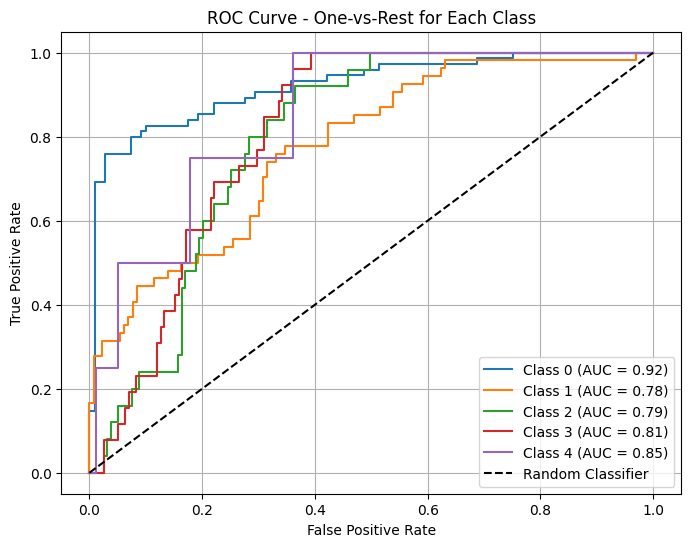

In [36]:
y_prob_all = model.predict_proba(X_test)

# Get unique classes
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(classes):
    # Get the probability scores for the current class
    y_prob_class = y_prob_all[:, i]

    # Calculate ROC curve and AUC for the current class (one-vs-rest)
    # y_true needs to be binarized for the current class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_class, pos_label=class_label)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-vs-Rest for Each Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Conclusion:

The Logistic Regression model successfully predicted heart disease risk with good accuracy. Feature scaling improved performance and ROC curve analysis showed the classification capability of the model.
